In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.legend_handler import HandlerTuple
from scipy.optimize import curve_fit
import os

In [3]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

## Load all data

In [37]:
save_dir = "Data/CW_Data/AttenuateCW/WeakCoherentSNSPDMeas_v5/TagProcessedData"

Data_30_70 = np.load(
    os.path.join(save_dir, "Tag_processed_30-70.npz")
)

veto_total_counts_30_70 = Data_30_70["veto_total_counts"]
veto_mean_rates_30_70 = Data_30_70["veto_mean_rates"]
veto_std_rates_30_70 = Data_30_70["veto_std_rates"]

distArr_measured = Data_30_70["distArr_measured"]

Data_70_30 = np.load(
    os.path.join(save_dir, "Tag_processed_70-30.npz")
)

veto_total_counts_70_30 = Data_70_30["veto_total_counts"]
veto_mean_rates_70_30 = Data_70_30["veto_mean_rates"]
veto_std_rates_70_30 = Data_70_30["veto_std_rates"]

distArr_measured = Data_70_30["distArr_measured"]

Data_80_20 = np.load(
    os.path.join(save_dir, "Tag_processed_80-20.npz")
)

veto_total_counts_80_20 = Data_80_20["veto_total_counts"]
veto_mean_rates_80_20 = Data_80_20["veto_mean_rates"]
veto_std_rates_80_20 = Data_80_20["veto_std_rates"]

distArr_measured = Data_80_20["distArr_measured"]



Data_20_80 = np.load(
    os.path.join(save_dir, "Tag_processed_20-80.npz")
)

veto_total_counts_20_80 = Data_20_80["veto_total_counts"]
veto_mean_rates_20_80 = Data_20_80["veto_mean_rates"]
veto_std_rates_20_80 = Data_20_80["veto_std_rates"]

#distArr_measured = Data_80_20["distArr_measured"]

Data_95_5 = np.load(
    os.path.join(save_dir, "Tag_processed_95-5.npz")
)

veto_total_counts_95_5 = Data_95_5["veto_total_counts"]
veto_mean_rates_95_5 = Data_95_5["veto_mean_rates"]
veto_std_rates_95_5 = Data_95_5["veto_std_rates"]

Data_5_95 = np.load(
    os.path.join(save_dir, "Tag_processed_5-95.npz")
)

veto_total_counts_5_95 = Data_5_95["veto_total_counts"]
veto_mean_rates_5_95 = Data_5_95["veto_mean_rates"]
veto_std_rates_5_95 = Data_5_95["veto_std_rates"]

Data_100_0 = np.load(
    os.path.join(save_dir, "Tag_processed_100-0.npz")
)

veto_total_counts_100_0 = Data_100_0["veto_total_counts"]
veto_mean_rates_100_0 = Data_100_0["veto_mean_rates"]
veto_std_rates_100_0 = Data_100_0["veto_std_rates"]

Data_0_100 = np.load(
    os.path.join(save_dir, "Tag_processed_0-100.npz")
)

veto_total_counts_0_100 = Data_0_100["veto_total_counts"]
veto_mean_rates_0_100 = Data_0_100["veto_mean_rates"]
veto_std_rates_0_100 = Data_0_100["veto_std_rates"]


# mean1_veto = veto_mean_rates[0]
# mean2_veto = veto_mean_rates[1]

# std1_veto = veto_std_rates[0]
# std2_veto = veto_std_rates[1]

# total1_veto = veto_total_counts[0]
# total2_veto = veto_total_counts[1]



In [38]:
def CalculateTheoryVelocities(eta, theta, phi0, N=50, step_nm=20.0, lambda_nm=925.0):
    # eta is a single fixed theory parameter
    # theta in degrees
    # phi0 is the initial phase in radians

    step_um = step_nm * 1e-3          # 20 nm = 0.02 micron
    lambda_um = lambda_nm * 1e-3      # 925 nm = 0.925 micron

    x_um = np.arange(N) * step_um     # 50 points: 0, 0.02, ..., 0.98 micron

    delta = np.sin(2 * np.radians(theta))**2
    epsilon = 1 - delta

    phi = phi0 + 4 * np.pi * x_um / lambda_um

    j = 0.5 * (1- 2 * eta)

    rho = 0.5 * (
        1
        + 2 * np.cos(phi) * np.sqrt(eta * (1 - eta)) * np.sqrt(epsilon)
    )

    Vel_value = j / rho

    Vel_vec = np.zeros((2, N))

    angle = np.arctan(Vel_value)

    Vx = np.sin(angle)
    Vy = np.cos(angle)

    Vel_vec[0, :] = Vx
    Vel_vec[1, :] = Vy

    Vel_mag = np.sqrt(Vx**2 + Vy**2)

    return Vel_vec, Vel_mag, Vel_value, phi, rho, j, x_um

In [39]:
def CalculateVelocities(CountsData, diff_const, theta, detect_eff_correction, exptData = False):        # theta in deg
    channelCount, distCount = CountsData.shape

    if exptData:                                                  # switch between the two num def if you want data for each point or just the base of the unwanted oscilations
        num = detect_eff_correction * CountsData[0, :] -  CountsData[1, :]
    else:
        num = diff_const
        
    den = detect_eff_correction * CountsData[0, :] +  CountsData[1, :]

    if theta != 0:
        #scale = np.sqrt(np.sin(2 * np.radians(theta)))
        scale = np.sin(2 * np.radians(theta))           # removed the square root as delta is actually (sin(2\theta))^2  dated 29012026
        Vel_value = num / (scale * den)      
    else:
        Vel_value = num / den
        print("You can't get velocity without hwp offset")

    Vel_vec = np.zeros((2, distCount))    
      

    angle = np.arctan(Vel_value)

    Vx = np.sin(angle)      # x component (space)
    Vy = np.cos(angle)      # t component (time, >0)

    Vel_vec[0, :] = Vx
    Vel_vec[1, :] = Vy

    Vel_mag = np.sqrt(Vx**2 + Vy**2)
    
    return Vel_vec, Vel_mag

In [40]:
def plot_interference_trace(
    dist,
    mean_rates,
    std_rates,
    split_ratio,
    fringe_start,
    theta=4.0,
    step_nm=20.0,
    lambda_nm=925.0,
    det_efficiency=0.66,    # 0.64 for 70-30, 0.66 for 30-70, 0.62 for the rest
    figsize=(4, 3.45)
):
    """
    Plot experimental  and theoretical sum of count rates 

    """

    x = np.asarray(dist, dtype=float)

    # ============================================================
    # Experimental sum
    # ============================================================
    y_sum =det_efficiency*mean_rates[0] + mean_rates[1]

    # Propagate independent channel uncertainties
    yerr_sum = np.sqrt(
        (det_efficiency*std_rates[0]
         )**2 +
        std_rates[1]**2
    )

    # Peak-normalise experiment
    experimental_norm = np.max(y_sum)


    y_sum_n = y_sum / experimental_norm
    yerr_sum_n = yerr_sum / experimental_norm

    # ============================================================
    # Theory
    # ============================================================
    eta = split_ratio[0] / 100.0
    phi0 = 2 * np.pi * fringe_start

    Vel_vec, Vel_mag, Vel_value, phi, rho, j, x_um = (
        CalculateTheoryVelocities(
            eta=eta,
            theta=theta,
            phi0=phi0,
            N=len(x),
            step_nm=step_nm,
            lambda_nm=lambda_nm
        )
    )

    rho = np.asarray(rho, dtype=float)
    rho_n = rho / np.max(rho)

    # ============================================================
    # Plot
    # ============================================================
    plt.figure(figsize=figsize)

    # Plot theory first so experimental points appear on top
    plt.plot(
        x_um,
        rho_n,
        linestyle="-",
        linewidth=2,
        alpha=0.8,
        color = 'orange',
        label=fr"Theory",
        zorder=1
    )

    plt.errorbar(
    x,
    y_sum_n,
    yerr=yerr_sum_n,
    fmt="o",
    markersize=4,      
    elinewidth=1.5,    # error-bar line thickness
    capsize=3,
    capthick=1.2,
    label="Experiment",
    zorder=2
)

    plt.xlabel(r"MBS Position ($\mu$m)", fontsize=12)
    plt.ylabel("Normalised sum of count rates", fontsize=12)

    # plt.title(
    #     f"Splitting ratio {split_ratio[0]}:{split_ratio[1]}"
    #     f"\nfringe_start = {fringe_start:.3f}"
    # )

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,1.2)

    plt.grid(alpha=0.2)
    plt.legend(fontsize=10, loc="upper left"),
    plt.tight_layout()
    #plt.show()

In [126]:
def plot_interference_trace(
    dist,
    mean_rates,
    std_rates,
    split_ratio,
    fringe_start,
    theta=4.0,
    step_nm=20.0,
    lambda_nm=925.0,
    det_efficiency=0.62,    # 0.64 for 70-30, 0.66 for 30-70, 0.62 for the rest
    figsize=(4.56, 4)
):
    

    x = np.asarray(dist, dtype=float)

    # ============================================================
    # Experimental sum and difference
    # ============================================================
    y_sum = det_efficiency * mean_rates[0] + mean_rates[1]
    y_diff = det_efficiency * mean_rates[0] - mean_rates[1]

    
    yerr = np.sqrt(
        (det_efficiency * std_rates[0])**2
        + std_rates[1]**2
    )

    # ============================================================
    # Peak normalisation
    # ============================================================
    experimental_norm = np.max(y_sum)

    y_sum_n = y_sum / experimental_norm
    y_diff_n = y_diff / experimental_norm
    yerr_n = yerr / experimental_norm

    # ============================================================
    # Theory
    # ============================================================
    eta = split_ratio[0] / 100.0
    phi0 = 2 * np.pi * fringe_start

    Vel_vec, Vel_mag, Vel_value, phi, rho, j, x_um = (
        CalculateTheoryVelocities(
            eta=eta,
            theta=theta,
            phi0=phi0,
            N=len(x),
            step_nm=step_nm,
            lambda_nm=lambda_nm
        )
    )

    # Theoretical sum
    rho = np.asarray(rho, dtype=float)
    rho_n = rho / np.max(rho)

    # Theoretical difference
    theory_diff = (1 - 2 * eta) * np.sin(2 * np.deg2rad(theta))

    # ============================================================
    # Plot
    # ============================================================
    plt.figure(figsize=figsize)

    # ------------------------------------------------------------
    # Theory
    # ------------------------------------------------------------

    # Theoretical sum
    plt.plot(
        x_um,
        rho_n,
        linestyle="-",
        linewidth=2,
        alpha=0.8,
        color="orange",
        label="Theory sum",
        zorder=1
    )

    # Theoretical difference
    plt.plot(
        x_um,
        np.full_like(x_um, theory_diff, dtype=float),
        linestyle="-",
        linewidth=2,
        alpha=0.8,
        color="sienna",
        label="Theory difference",
        zorder=1
    )

    # ------------------------------------------------------------
    # Experiment
    # ------------------------------------------------------------

    # Experimental sum
    plt.errorbar(
        x,
        y_sum_n,
        yerr=yerr_n,
        fmt="o",
        markersize=4,
        elinewidth=1.5,
        capsize=3,
        capthick=1.2,
        label="Experiment sum",
        color = "tab:blue",
        zorder=3
    )

    # Experimental difference
    plt.errorbar(
        x,
        y_diff_n,
        yerr=yerr_n,
        fmt="s",
        markersize=3,
        elinewidth=1.0,
        capsize=3,
        capthick=1.0,
        color= "teal",
        label="Experiment difference",
        zorder=2
    )

    # ============================================================
    # Formatting
    # ============================================================
    plt.xlabel(r"MBS Position ($\mu$m)", fontsize=12)
    plt.ylabel(r"Normalised count rates ($\rm s^{-1}$)", fontsize=12)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.ylim(-0.2, 1.2)

    plt.grid(alpha=0.15)
    plt.legend(fontsize=10, loc="upper left")

    plt.tight_layout()


### 70-30

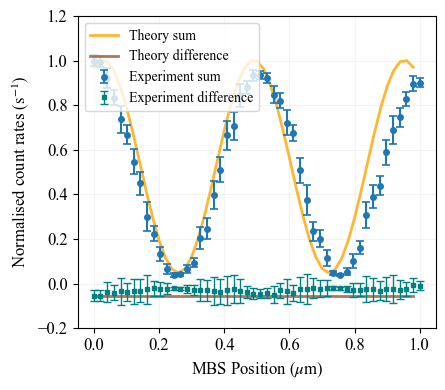

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_70_30,
    std_rates=veto_std_rates_70_30,
    split_ratio=(70, 30),
    fringe_start=-0.06,
    det_efficiency=0.64
)
# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_70_30.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

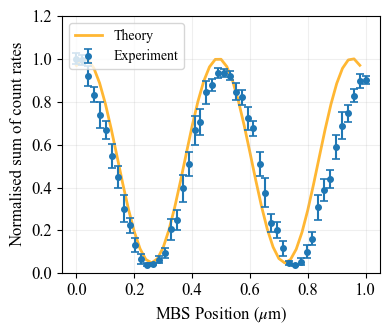

In [41]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_70_30,
    std_rates=veto_std_rates_70_30,
    split_ratio=(70, 30),
    fringe_start=-0.06
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_70-30.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 30-70

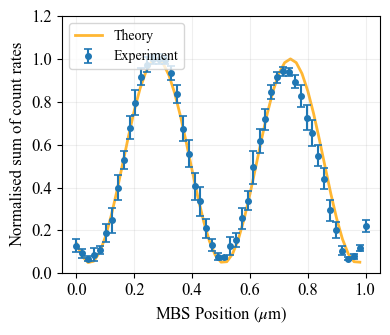

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_30_70,
    std_rates=veto_std_rates_30_70,
    split_ratio=(30, 70),
    fringe_start=0.40
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_30-70.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

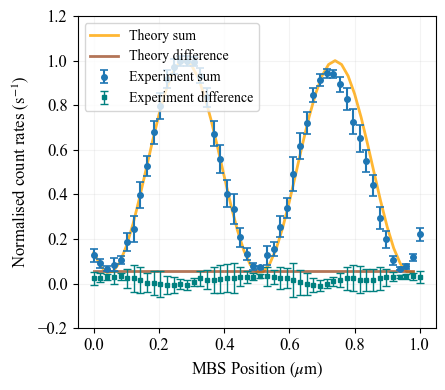

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_30_70,
    std_rates=veto_std_rates_30_70,
    split_ratio=(30, 70),
    fringe_start=0.40
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_30_70.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 80-20

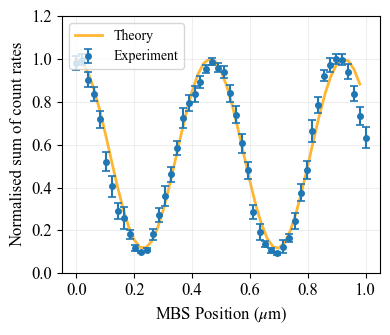

In [9]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_80_20,
    std_rates=veto_std_rates_80_20,
    split_ratio=(80, 20),
    fringe_start=0.0
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_80-20.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

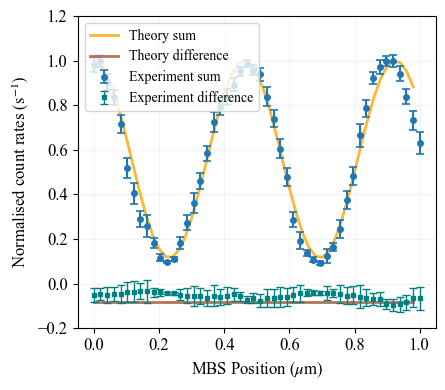

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_80_20,
    std_rates=veto_std_rates_80_20,
    split_ratio=(80, 20),
    fringe_start=0.0
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_80-20.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()

### 20-80

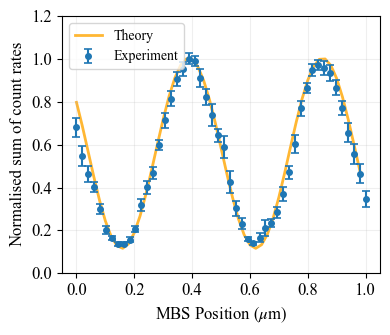

In [10]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_20_80,
    std_rates=veto_std_rates_20_80,
    split_ratio=(20, 80),
    fringe_start=0.16
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_20-80.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

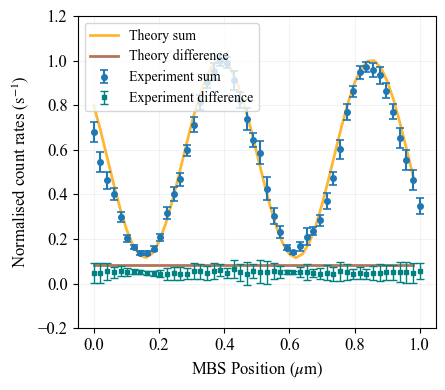

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_20_80,
    std_rates=veto_std_rates_20_80,
    split_ratio=(20, 80),
    fringe_start=0.16
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_20-80.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()

### 95-5

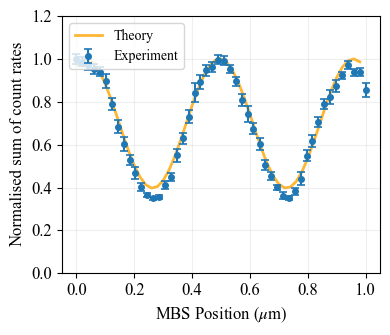

In [11]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_95_5,
    std_rates=veto_std_rates_95_5,
    split_ratio=(95, 5),
    fringe_start=-0.07
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_95-5.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

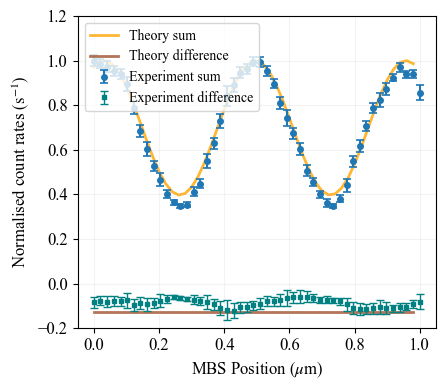

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_95_5,
    std_rates=veto_std_rates_95_5,
    split_ratio=(95, 5),
    fringe_start=-0.07,
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_95-5.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 5-95

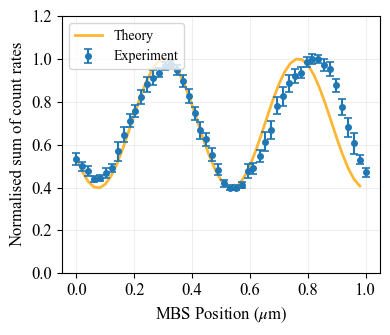

In [13]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_5_95,
    std_rates=veto_std_rates_5_95,
    split_ratio=(5, 95),
    fringe_start=0.34
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_5-95.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

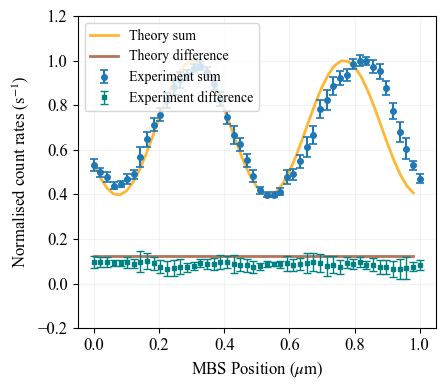

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_5_95,
    std_rates=veto_std_rates_5_95,
    split_ratio=(5, 95),
    fringe_start=0.34,
)
# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_5-95.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 100-0

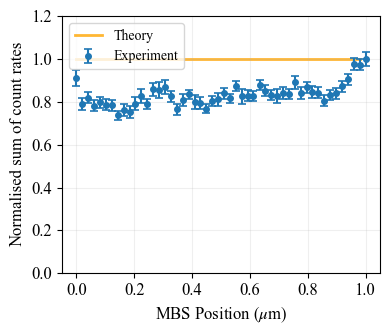

In [14]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_100_0,
    std_rates=veto_std_rates_100_0,
    split_ratio=(100, 0),
    fringe_start=0
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_100-0.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

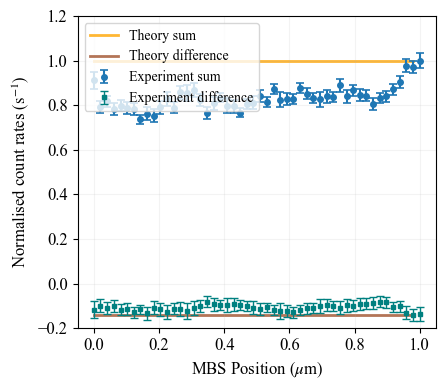

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_100_0,
    std_rates=veto_std_rates_100_0,
    split_ratio=(100, 0),
    fringe_start=0.0,
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_100-0.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()

### 0-100

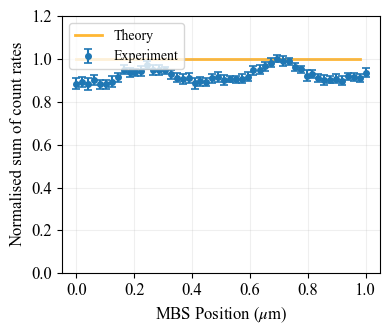

In [15]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_0_100,
    std_rates=veto_std_rates_0_100,
    split_ratio=(0, 100),
    fringe_start=0
)

# plt.savefig(
#     "forExpt_draft/fringes/fringe_0-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

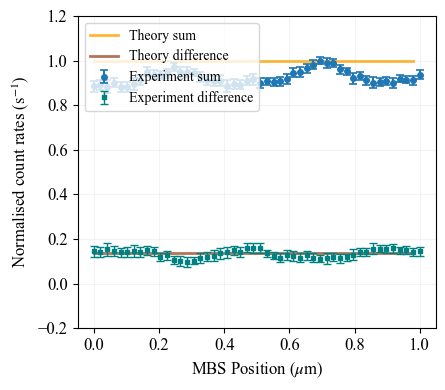

In [ ]:
plot_interference_trace(
    dist=distArr_measured,
    mean_rates=veto_mean_rates_0_100,
    std_rates=veto_std_rates_0_100,
    split_ratio=(0, 100),
    fringe_start=0.0,
)

# plt.savefig(
#     "forExpt_draft/counts_sum_diff/counts_0-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

plt.show()

# Trajectories

In [28]:
## experimental velocity vectors
theta_exp = 4.0
detect_eff_correction = 0.66 ## factor derived from coupling effeciency and the detction effeciency of SNSPD channels

# ============================================================
# Experimental velocities: 30:70
# ============================================================
Vel_vec_exp_30_70, Vel_mag_exp_30_70 = CalculateVelocities(
    CountsData=veto_mean_rates_30_70,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_30_70 = Vel_vec_exp_30_70[0]
Vy_exp_30_70 = Vel_vec_exp_30_70[1]

In [27]:
## experimental velocity vectors
theta_exp = 4.0
detect_eff_correction = 0.64 ## factor derived from coupling effeciency and the detction effeciency of SNSPD channels

# ============================================================
# Experimental velocities: 70:30
# ============================================================
Vel_vec_exp_70_30, Vel_mag_exp_70_30 = CalculateVelocities(
    CountsData=veto_mean_rates_70_30,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_70_30 = Vel_vec_exp_70_30[0]
Vy_exp_70_30 = Vel_vec_exp_70_30[1]

In [16]:
## experimental velocity vectors
theta_exp = 4.0
detect_eff_correction = 0.62 ## factor derived from coupling effeciency and the detction effeciency of SNSPD channels

# ============================================================
# Experimental velocities: 80:20
# ============================================================
Vel_vec_exp_80_20, Vel_mag_exp_80_20 = CalculateVelocities(
    CountsData=veto_mean_rates_80_20,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_80_20 = Vel_vec_exp_80_20[0]
Vy_exp_80_20 = Vel_vec_exp_80_20[1]


# ============================================================
# Experimental velocities: 20:80
# ============================================================
Vel_vec_exp_20_80, Vel_mag_exp_20_80 = CalculateVelocities(
    CountsData=veto_mean_rates_20_80,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_20_80 = Vel_vec_exp_20_80[0]
Vy_exp_20_80 = Vel_vec_exp_20_80[1]


# ============================================================
# Experimental velocities: 95:5
# ============================================================
Vel_vec_exp_95_5, Vel_mag_exp_95_5 = CalculateVelocities(
    CountsData=veto_mean_rates_95_5,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_95_5 = Vel_vec_exp_95_5[0]
Vy_exp_95_5 = Vel_vec_exp_95_5[1]


# ============================================================
# Experimental velocities: 5:95
# ============================================================
Vel_vec_exp_5_95, Vel_mag_exp_5_95 = CalculateVelocities(
    CountsData=veto_mean_rates_5_95,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_5_95 = Vel_vec_exp_5_95[0]
Vy_exp_5_95 = Vel_vec_exp_5_95[1]


# ============================================================
# Experimental velocities: 100:0
# ============================================================
Vel_vec_exp_100_0, Vel_mag_exp_100_0 = CalculateVelocities(
    CountsData=veto_mean_rates_100_0,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_100_0 = Vel_vec_exp_100_0[0]
Vy_exp_100_0 = Vel_vec_exp_100_0[1]


# ============================================================
# Experimental velocities: 0:100
# ============================================================
Vel_vec_exp_0_100, Vel_mag_exp_0_100 = CalculateVelocities(
    CountsData=veto_mean_rates_0_100,
    diff_const=0.0,
    theta=theta_exp,
    detect_eff_correction=detect_eff_correction,
    exptData=True
)

Vx_exp_0_100 = Vel_vec_exp_0_100[0]
Vy_exp_0_100 = Vel_vec_exp_0_100[1]

In [29]:
N = len(distArr_measured)

n_rows_top = 100
n_rows_bottom = 100

dx = 0.02
dy = 0.02

# Ideal 50:50 full-visibility density:
# minimum rho = 0
# maximum rho = 1
# mean rho = 0.5

reference_integral = (
    0.5
    * N
    * (n_rows_top + n_rows_bottom)
    * dx
    * dy
)

density_norm_50_50 = Normalize(
    vmin=0.0,
    vmax=1.0 / reference_integral,
    clip=True
)

print("Shared colour maximum =", density_norm_50_50.vmax, "μm⁻²")

Shared colour maximum = 0.5 μm⁻²


## Selecting experimental data for a splitting ratio and plotting (can do function but individual is better here as there are not too many splitting ratios and this process is more transparent)

### colour for traj and denisty

In [30]:
TRAJ = "#F25F1F"
# TRAJ = "#F58A1F"

# DENSITY_COLORS = (
#     "#7BB1C9",
#     "#9FC4D4",
#     "#BDD8E3",
#     "#D8E9F0",
#     "#EFF7FA",
# )

DENSITY_COLORS = (
    "#2F6F8F",  # deep blue
    "#5F95AE",
    "#8FB6C8",
    "#BDD8E3",
    "#EFF7FA",  # very light blue
)

density_cmap = LinearSegmentedColormap.from_list(
    "muted_blue_density",
    DENSITY_COLORS,
    N=256
)

Experimental area normalisation = 0.9999999999999999
Theoretical area normalisation = 1.0


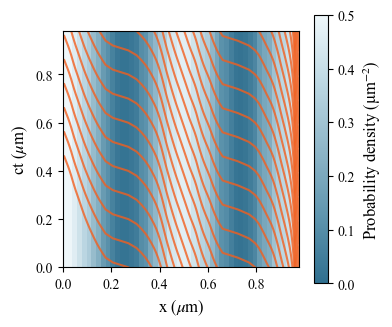

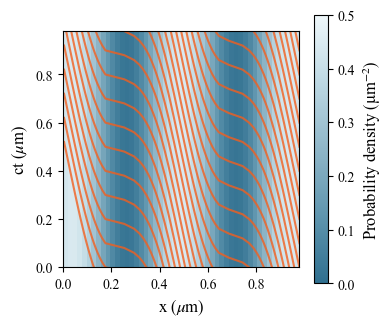

In [ ]:

# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_70_30

mean1_n = veto_mean_rates_70_30[0]
mean2_n = veto_mean_rates_70_30[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.7
theta_theory = 4.0
fringe_start = -0.06

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

right_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# EXPERIMENTAL probability density
# ============================================================
prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# ============================================================
# THEORETICAL probability density

# ============================================================
prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)


#  density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)


# AXIS SETTINGS

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy


# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Experimental trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Experimental colourbar
# ------------------------------------------------------------
cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp,
    ticks=density_ticks
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Experimental axes
# ------------------------------------------------------------
ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_70-30_expt.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Theoretical trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Theory colourbar
# ------------------------------------------------------------
cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th,
    ticks=density_ticks
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_70-30_theory.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

### 30-70

Experimental area normalisation = 1.0000000000000002
Theoretical area normalisation = 1.0


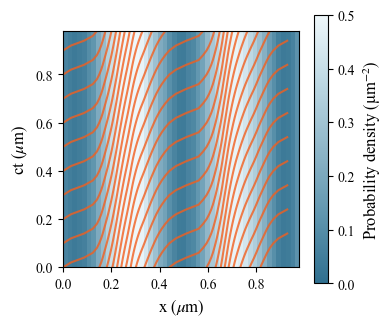

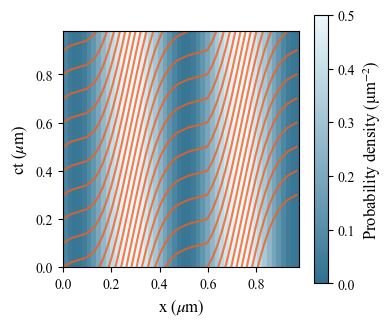

In [ ]:
# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_30_70

mean1_n = veto_mean_rates_30_70[0]
mean2_n = veto_mean_rates_30_70[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.3
theta_theory = 4.0
fringe_start = 0.40

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]

# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# Experimental probability density

prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# Theoretical probability density

prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)

# density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)

# Axis settings

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Experimental trajectories

for j0 in left_start_rows:

    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )



# Experimental colourbar

cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# Experimental axes

ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_30-70_expt.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Theoretical trajectories

for j0 in left_start_rows:

    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx_th
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy_th
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# Theory colourbar

cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_30-70_theory.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

### 20-80

Experimental area normalisation = 0.9999999999999998
Theoretical area normalisation = 1.0


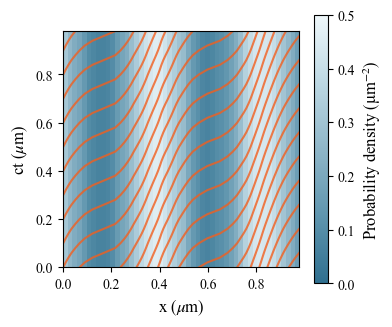

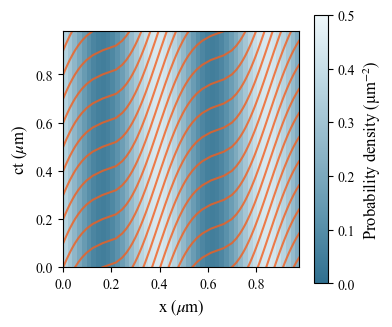

In [ ]:
# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_20_80

mean1_n = veto_mean_rates_20_80[0]
mean2_n = veto_mean_rates_20_80[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.2
theta_theory = 4.0
fringe_start = 0.16

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]

# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# Experimental probability density

prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# Theoretical probability density

prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)

# density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)

# Axis settings

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Experimental trajectories

for j0 in left_start_rows:

    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )



# Experimental colourbar

cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# Experimental axes

ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_20-80_expt.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Theoretical trajectories

for j0 in left_start_rows:

    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx_th
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy_th
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# Theory colourbar

cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_20-80_theory.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

### 80-20

Experimental area normalisation = 0.9999999999999999
Theoretical area normalisation = 1.0


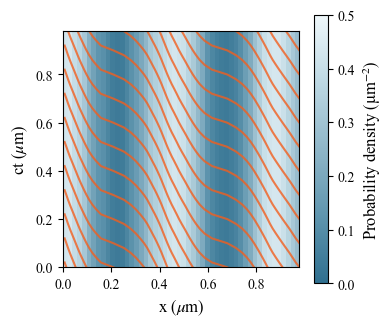

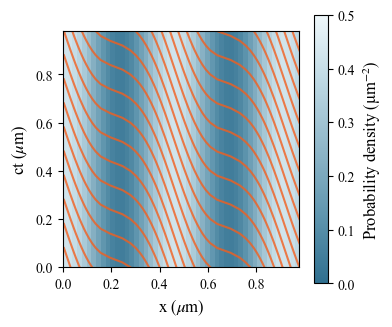

In [ ]:

# Select experimental data for this splitting ratio

mean1_n = veto_mean_rates_80_20[0]
mean2_n = veto_mean_rates_80_20[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.8
theta_theory = 4.0
fringe_start = 0.0

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

right_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# EXPERIMENTAL probability density
# ============================================================
prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# ============================================================
# THEORETICAL probability density

# ============================================================
prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)


#  density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)


# AXIS SETTINGS

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy


# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Experimental trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Experimental colourbar
# ------------------------------------------------------------
cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp,
    ticks=density_ticks
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Experimental axes
# ------------------------------------------------------------
ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_80-20_expt.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Theoretical trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Theory colourbar
# ------------------------------------------------------------
cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th,
    ticks=density_ticks
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_80-20_theory.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

Discrete sum = 2499.9999999999995
Area normalisation = 0.9999999999999999


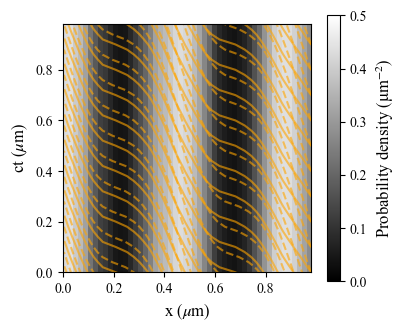

In [ ]:
# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_80_20

mean1_n = veto_mean_rates_80_20[0]
mean2_n = veto_mean_rates_80_20[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities (also choose parameters here)
# ============================================================
eta = 0.8
theta_theory = 4.0
fringe_start = 0.0

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(
    prob_1d,
    (n_rows_top + n_rows_bottom, 1)
)


prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(4, 3.45))

plt.imshow(
    prob_2d,
    origin="lower",
    aspect="equal",
    cmap="gray",
    norm=density_norm_50_50,
    extent=[0, N - 1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)

right_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# Experimental trajectories: 
# ============================================================
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(
        xs,
        ys,
        linewidth=1.5,
        color="orange",
        alpha = 0.6
    )


# ============================================================
# Theoretical trajectories:
# ============================================================
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(
        xs_th,
        ys_th,
        "--",
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )


# Axes

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(
    xticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.yticks(
    yticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlim(0, N - 1)
plt.ylim(0, N - 1)

plt.grid(False)

# plt.savefig(
#     "forExpt_draft/traj_v2/traj_80-20.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 5-95

Experimental area normalisation = 1.0
Theoretical area normalisation = 0.9999999999999999


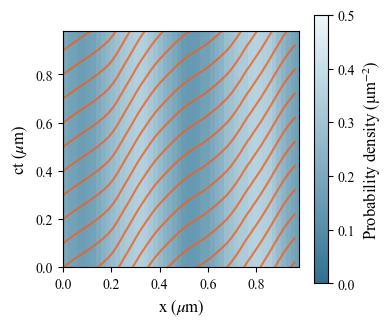

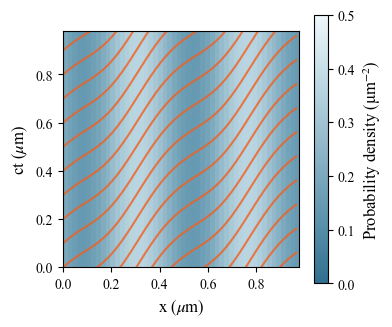

In [ ]:
# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_5_95

mean1_n = veto_mean_rates_5_95[0]
mean2_n = veto_mean_rates_5_95[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.05
theta_theory = 4.0
fringe_start = 0.34

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]

# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# Experimental probability density

prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# Theoretical probability density

prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)

# density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)

# Axis settings

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Experimental trajectories

for j0 in left_start_rows:

    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )



# Experimental colourbar

cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# Experimental axes

ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_5-95_expt.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Theoretical trajectories

for j0 in left_start_rows:

    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx_th
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy_th
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# Theory colourbar

cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_5-95_theory.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

Discrete sum = 2500.0
Area normalisation = 1.0


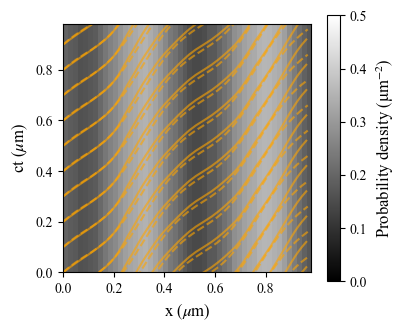

In [ ]:

Vel_vec = Vel_vec_exp_5_95

mean1_n = veto_mean_rates_5_95[0]
mean2_n = veto_mean_rates_5_95[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities (also choose parameters here)
# ============================================================
eta = 0.05
theta_theory = 4.0
fringe_start = 0.34

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(
    prob_1d,
    (n_rows_top + n_rows_bottom, 1)
)


prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(4, 3.45))

plt.imshow(
    prob_2d,
    origin="lower",
    aspect="equal",
    cmap="gray",
    norm=density_norm_50_50,
    extent=[0, N - 1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# Experimental trajectories: 
# ============================================================
for j0 in left_start_rows:
    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(
        xs,
        ys,
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )


# ============================================================
# Theoretical trajectories:
# ============================================================
for j0 in left_start_rows:
    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(
        xs_th,
        ys_th,
        "--",
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )



# Axes

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(
    xticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.yticks(
    yticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlim(0, N - 1)
plt.ylim(0, N - 1)

plt.grid(False)

# plt.savefig(
#     "forExpt_draft/traj_v2/traj_5-95.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 95-5

Experimental area normalisation = 1.0
Theoretical area normalisation = 1.0000000000000002


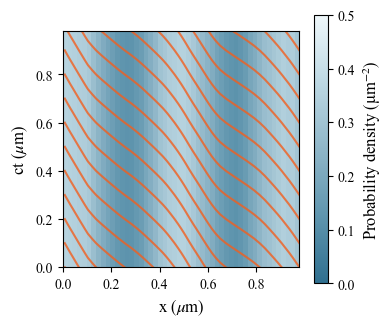

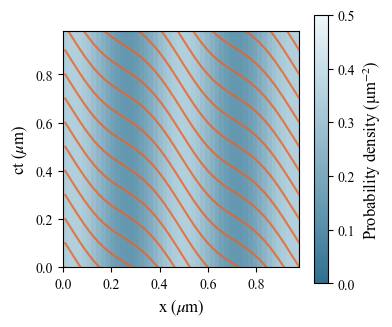

In [ ]:

# Select experimental data for this splitting ratio
Vel_vec = Vel_vec_exp_95_5

mean1_n = veto_mean_rates_95_5[0]
mean2_n = veto_mean_rates_95_5[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.95
theta_theory = 4.0
fringe_start = -0.07

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# EXPERIMENTAL probability density
# ============================================================
prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# ============================================================
# THEORETICAL probability density

# ============================================================
prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)


#  density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)


# AXIS SETTINGS

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy


# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Experimental trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Experimental colourbar
# ------------------------------------------------------------
cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp,
    ticks=density_ticks
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Experimental axes
# ------------------------------------------------------------
ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_95-5_expt.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Theoretical trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Theory colourbar
# ------------------------------------------------------------
cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th,
    ticks=density_ticks
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_95-5_theory.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

Discrete sum = 2500.0
Area normalisation = 1.0


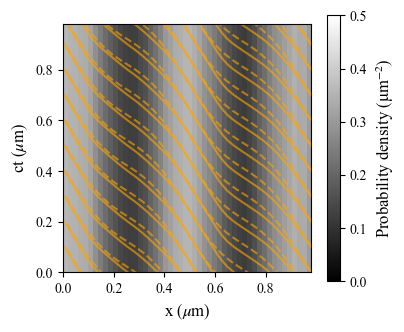

In [ ]:

Vel_vec = Vel_vec_exp_95_5

mean1_n = veto_mean_rates_95_5[0]
mean2_n = veto_mean_rates_95_5[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities
# ============================================================
eta = 0.95
theta_theory = 4.0
fringe_start = -0.07

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(
    prob_1d,
    (n_rows_top + n_rows_bottom, 1)
)

# Keep your original normalization unchanged
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(4, 3.45))

plt.imshow(
    prob_2d,
    origin="lower",
    aspect="equal",
    cmap="gray",
    norm=density_norm_50_50,
    extent=[0, N - 1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)

right_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# Experimental trajectories: 
# ============================================================
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(
        xs,
        ys,
        linewidth=1.5,
        color="orange",
        alpha = 0.6
    )


# ============================================================
# Theoretical trajectories: (also choose parameters here)
# ============================================================
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(
        xs_th,
        ys_th,
        "--",
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )


# Axes

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(
    xticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.yticks(
    yticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlim(0, N - 1)
plt.ylim(0, N - 1)

plt.grid(False)
# plt.savefig(
#     "forExpt_draft/traj_v2/traj_95-5.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 0-100

Experimental area normalisation = 0.9999999999999998
Theoretical area normalisation = 1.0


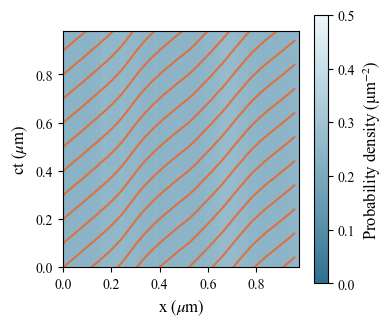

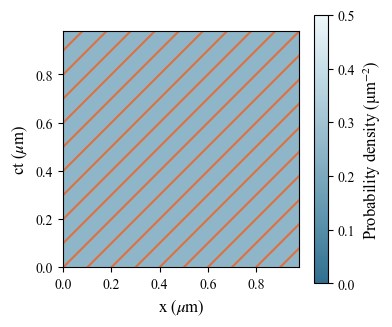

In [ ]:
# Select experimental data for this splitting ratio

Vel_vec = Vel_vec_exp_0_100

mean1_n = veto_mean_rates_0_100[0]
mean2_n = veto_mean_rates_0_100[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 0.00
theta_theory = 4.0
fringe_start = 0.0

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]

# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# Experimental probability density

prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# Theoretical probability density

prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)

# density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)

# Axis settings

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Experimental trajectories

for j0 in left_start_rows:

    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )



# Experimental colourbar

cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# Experimental axes

ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_0-100_expt.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )

# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# Theoretical trajectories

for j0 in left_start_rows:

    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):

        vx = np.interp(
            x_current,
            np.arange(N),
            Vx_th
        )

        vy = np.interp(
            x_current,
            np.arange(N),
            Vy_th
        )

        if abs(vy) < 1e-12:
            break

        x_next = (
            x_current
            + (vx / vy) * y_spacing
        )

        y_next = (
            y_current
            + y_spacing
        )

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# Theory colourbar

cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_0-100_theory.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

Discrete sum = 2499.999999999999
Area normalisation = 0.9999999999999998


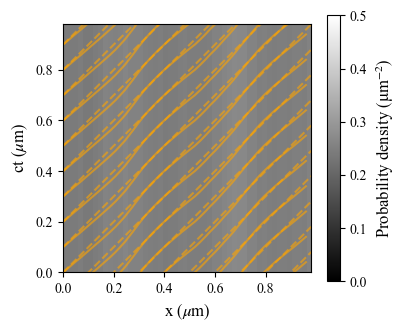

In [ ]:
# Select experimental data for this splitting ratio
Vel_vec = Vel_vec_exp_0_100

mean1_n = veto_mean_rates_0_100[0]
mean2_n = veto_mean_rates_0_100[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities (choose parameters)
# ============================================================
eta = 0.0
theta_theory = 4.0
fringe_start = 0.0

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(
    prob_1d,
    (n_rows_top + n_rows_bottom, 1)
)


prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing


# Plot

plt.figure(figsize=(4, 3.45))

plt.imshow(
    prob_2d,
    origin="lower",
    aspect="equal",
    cmap="gray",
    norm=density_norm_50_50,
    extent=[0, N - 1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# Experimental trajectories: 
# ============================================================
for j0 in left_start_rows:
    xs = [0]
    ys = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(
        xs,
        ys,
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )


# ============================================================
# Theoretical trajectories:
# ============================================================
for j0 in left_start_rows:
    xs_th = [0]
    ys_th = [j0 * y_spacing]

    x_current = 0.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(
        xs_th,
        ys_th,
        "--",
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )



# Axes

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(
    xticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.yticks(
    yticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlim(0, N - 1)
plt.ylim(0, N - 1)

plt.grid(False)

# plt.savefig(
#     "forExpt_draft/traj_v2/traj_0-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

### 100-0

Experimental area normalisation = 1.0
Theoretical area normalisation = 1.0


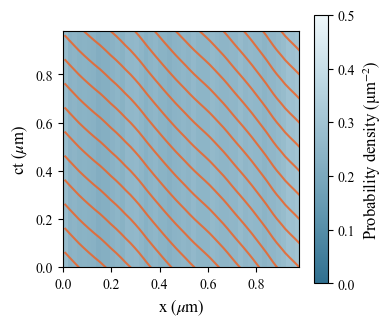

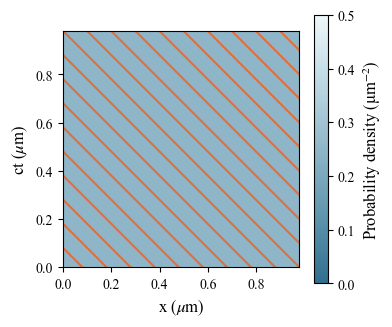

In [ ]:

# ============================================================
# Select experimental data for this splitting ratio
# ============================================================
Vel_vec = Vel_vec_exp_100_0

mean1_n = veto_mean_rates_100_0[0]
mean2_n = veto_mean_rates_100_0[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# Theoretical velocities and density

eta = 1.0
theta_theory = 4.0
fringe_start = 0.00

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# Grid parameters

N = Vx.size

n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing

left_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# EXPERIMENTAL probability density
# ============================================================
prob_1d_exp = mean1_n + mean2_n

prob_1d_exp = np.asarray(prob_1d_exp, dtype=float)
prob_1d_exp = np.nan_to_num(prob_1d_exp, nan=0.0)
prob_1d_exp[prob_1d_exp < 0] = 0.0

prob_2d_exp = np.tile(
    prob_1d_exp,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_exp /= np.sum(prob_2d_exp) * dx * dy

print(
    "Experimental area normalisation =",
    np.sum(prob_2d_exp) * dx * dy
)


# ============================================================
# THEORETICAL probability density

# ============================================================
prob_1d_th = np.asarray(rho_th, dtype=float)

prob_1d_th = np.nan_to_num(
    prob_1d_th,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

prob_1d_th[prob_1d_th < 0] = 0.0

prob_2d_th = np.tile(
    prob_1d_th,
    (n_rows_top + n_rows_bottom, 1)
)

# Area normalisation
prob_2d_th /= np.sum(prob_2d_th) * dx * dy

print(
    "Theoretical area normalisation =",
    np.sum(prob_2d_th) * dx * dy
)


#  density scale for both plots

density_norm = Normalize(
    vmin=0.0,
    vmax=0.5,
    clip=True
)

density_ticks = np.arange(0.0, 0.51, 0.1)


# AXIS SETTINGS

ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy


# ============================================================
# PLOT 1: EXPERIMENT
# ============================================================

fig_exp, ax_exp = plt.subplots(
    figsize=(4, 3.45)
)

image_exp = ax_exp.imshow(
    prob_2d_exp,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Experimental trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    ax_exp.plot(
        xs,
        ys,
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Experimental colourbar
# ------------------------------------------------------------
cbar_exp = fig_exp.colorbar(
    image_exp,
    ax=ax_exp,
    ticks=density_ticks
)

cbar_exp.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Experimental axes
# ------------------------------------------------------------
ax_exp.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_exp.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_exp.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_exp.set_aspect(
    "equal",
    adjustable="box"
)

ax_exp.set_xlim(
    0,
    N - 1
)

ax_exp.set_ylim(
    0,
    N - 1
)

ax_exp.grid(False)

fig_exp.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_100-0_expt.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# PLOT 2: THEORY
# ============================================================

fig_th, ax_th = plt.subplots(
    figsize=(4, 3.45)
)

image_th = ax_th.imshow(
    prob_2d_th,
    origin="lower",
    aspect="equal",
    cmap=density_cmap,
    norm=density_norm,
    extent=[
        0,
        N - 1,
        y_vals[0],
        y_vals[-1]
    ],
    interpolation="nearest"
)


# ------------------------------------------------------------
# Theoretical trajectories
# ------------------------------------------------------------
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    ax_th.plot(
        xs_th,
        ys_th,
        "-",
        linewidth=1.5,
        color=TRAJ,
        alpha=0.8
    )


# ------------------------------------------------------------
# Theory colourbar
# ------------------------------------------------------------
cbar_th = fig_th.colorbar(
    image_th,
    ax=ax_th,
    ticks=density_ticks
)

cbar_th.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)


# ------------------------------------------------------------
# Theory axes
# ------------------------------------------------------------
ax_th.set_xticks(
    xticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_yticks(
    yticks,
    [f"{tick:.1f}" for tick in ticksforfig]
)

ax_th.set_xlabel(
    "x ($\\mu$m)",
    fontsize=12
)

ax_th.set_ylabel(
    "ct ($\\mu$m)",
    fontsize=12
)

ax_th.set_aspect(
    "equal",
    adjustable="box"
)

ax_th.set_xlim(
    0,
    N - 1
)

ax_th.set_ylim(
    0,
    N - 1
)

ax_th.grid(False)

fig_th.tight_layout()

# plt.savefig(
#     "forExpt_draft/traj_v4/traj_100-0_theory.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )


# ============================================================
# Show both figures
# ============================================================
plt.show()

Discrete sum = 2500.0
Area normalisation = 1.0


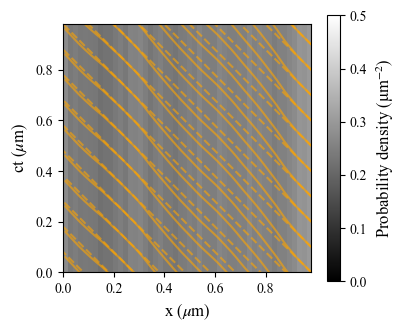

In [ ]:

Vel_vec = Vel_vec_exp_100_0

mean1_n = veto_mean_rates_100_0[0]
mean2_n = veto_mean_rates_100_0[1]

Vx = Vel_vec[0, :]
Vy = Vel_vec[1, :]


# ============================================================
# Theoretical velocities
# ============================================================
eta = 1.0
theta_theory = 4.0
fringe_start = 0.0

phi0 = 2 * np.pi * fringe_start

Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
    CalculateTheoryVelocities(
        eta=eta,
        theta=theta_theory,
        phi0=phi0,
        N=len(Vx),
        step_nm=20.0,
        lambda_nm=925.0
    )
)

Vx_th = Vel_vec_th[0, :]
Vy_th = Vel_vec_th[1, :]


# ============================================================
# Probability density background from experiment
# ============================================================
N = Vx.size
n_rows_top = 100
n_rows_bottom = 100
y_spacing = 1

dx = 0.02
dy = 0.02

prob_1d = mean1_n + mean2_n
prob_1d = np.asarray(prob_1d, dtype=float)
prob_1d = np.nan_to_num(prob_1d, nan=0.0)
prob_1d[prob_1d < 0] = 0

prob_2d = np.tile(
    prob_1d,
    (n_rows_top + n_rows_bottom, 1)
)

# Keep your original normalization unchanged
prob_2d /= np.sum(prob_2d) * dx * dy

print("Discrete sum =", np.sum(prob_2d))
print("Area normalisation =", np.sum(prob_2d) * dx * dy)

y_vals = np.arange(
    -n_rows_bottom,
    n_rows_top
) * y_spacing


# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(4, 3.45))

plt.imshow(
    prob_2d,
    origin="lower",
    aspect="equal",
    cmap="gray",
    norm=density_norm_50_50,
    extent=[0, N - 1, y_vals[0], y_vals[-1]]
)

cbar = plt.colorbar()
cbar.set_label(
    "Probability density (μm$^{-2}$)",
    fontsize=12
)

right_start_rows = np.arange(
    -n_rows_bottom,
    n_rows_top,
    5
)


# ============================================================
# Experimental trajectories: 
# ============================================================
for j0 in right_start_rows:
    xs = [N - 1]
    ys = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx)
        vy = np.interp(x_current, np.arange(N), Vy)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs.append(x_current)
        ys.append(y_current)

    plt.plot(
        xs,
        ys,
        linewidth=1.5,
        color="orange",
        alpha = 0.6
    )


# ============================================================
# Theoretical trajectories:
# ============================================================
for j0 in right_start_rows:
    xs_th = [N - 1]
    ys_th = [j0 * y_spacing]

    x_current = N - 1.0
    y_current = j0 * y_spacing

    for step in range(n_rows_top + n_rows_bottom):
        vx = np.interp(x_current, np.arange(N), Vx_th)
        vy = np.interp(x_current, np.arange(N), Vy_th)

        if abs(vy) < 1e-12:
            break

        x_next = x_current + (vx / vy) * y_spacing
        y_next = y_current + y_spacing

        if x_next < 0 or x_next > N - 1:
            break

        if y_next > y_vals[-1]:
            break

        x_current = x_next
        y_current = y_next

        xs_th.append(x_current)
        ys_th.append(y_current)

    plt.plot(
        xs_th,
        ys_th,
        "--",
        linewidth=1.5,
        color="orange",
        alpha=0.6
    )


# ============================================================
# Axes
# ============================================================
ticksforfig = np.arange(0, 1, 0.2)

xticks = ticksforfig / dx
yticks = ticksforfig / dy

plt.xticks(
    xticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.yticks(
    yticks,
    [f"{ticks:.1f}" for ticks in ticksforfig]
)

plt.xlabel("x ($\\mu$m)", fontsize=12)
plt.ylabel("ct ($\\mu$m)", fontsize=12)

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.xlim(0, N - 1)
plt.ylim(0, N - 1)

plt.grid(False)

# plt.savefig(
#     "forExpt_draft/traj_v2/traj_100-0.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

## Vectors

In [ ]:
def plot_experimental_vectors(
    Vel_vec,
    split_ratio,
    step_um=0.02,
    tick_step=10,
    figsize=(22, 4),
    ylim=(-1, 2),
    arrow_scale=1,
    title=True
):
    


    Vel_vec = np.asarray(Vel_vec, dtype=float)

    Vx = Vel_vec[0, :]
    Vy = Vel_vec[1, :]

    N = Vx.size

    x_positions = np.arange(N)
    y_positions = np.zeros(N)

    fig, ax = plt.subplots(figsize=figsize)

    ax.quiver(
        x_positions,
        y_positions,
        Vx,
        Vy,
        angles="xy",
        scale_units="xy",
        scale=arrow_scale,
        width=0.002,
        headwidth=3,
        headlength=3,
        headaxislength=2
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.set_xlim(-1, N)
    ax.set_ylim(*ylim)

    # Convert array indices to physical MBS positions
    tick_positions = np.arange(0, N, tick_step)
    tick_labels = tick_positions * step_um

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [f"{position:.1f}" for position in tick_labels],
        fontsize=25
    )

    ax.set_yticks([])

    ax.set_xlabel(
        r"MBS position ($\mu$m)",
        fontsize=25
    )

    if title:
        ax.set_title(
            f"Experimental velocity vectors: "
            f"{split_ratio[0]}:{split_ratio[1]}",
            fontsize=22
        )

    ax.grid(False)

    fig.tight_layout()
    plt.show()

    return fig, ax

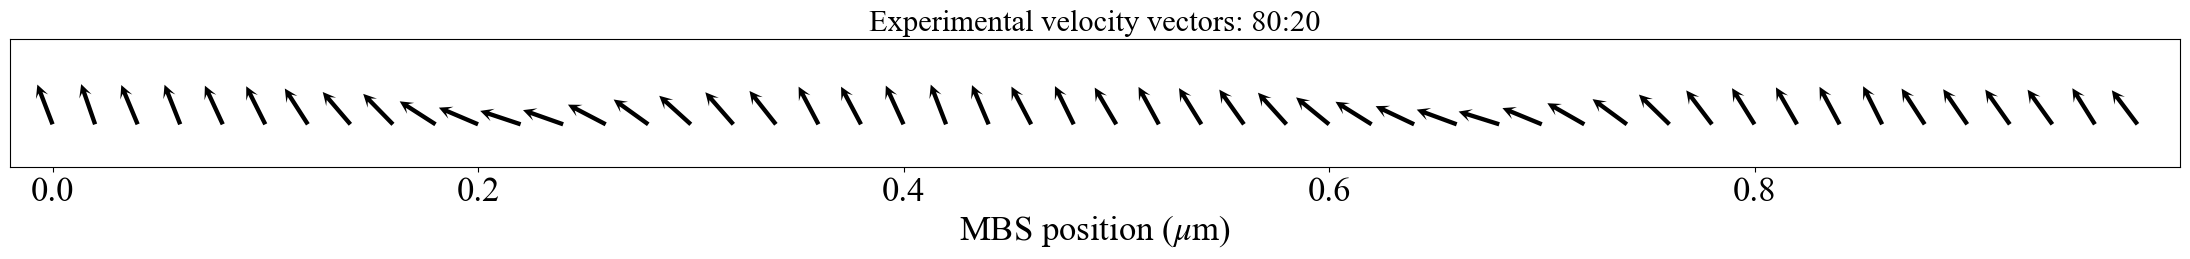

(<Figure size 2200x400 with 1 Axes>,
 <Axes: title={'center': 'Experimental velocity vectors: 80:20'}, xlabel='MBS position ($\\mu$m)'>)

In [25]:
plot_experimental_vectors(
    Vel_vec=Vel_vec_exp_80_20,
    split_ratio=(80, 20)
)

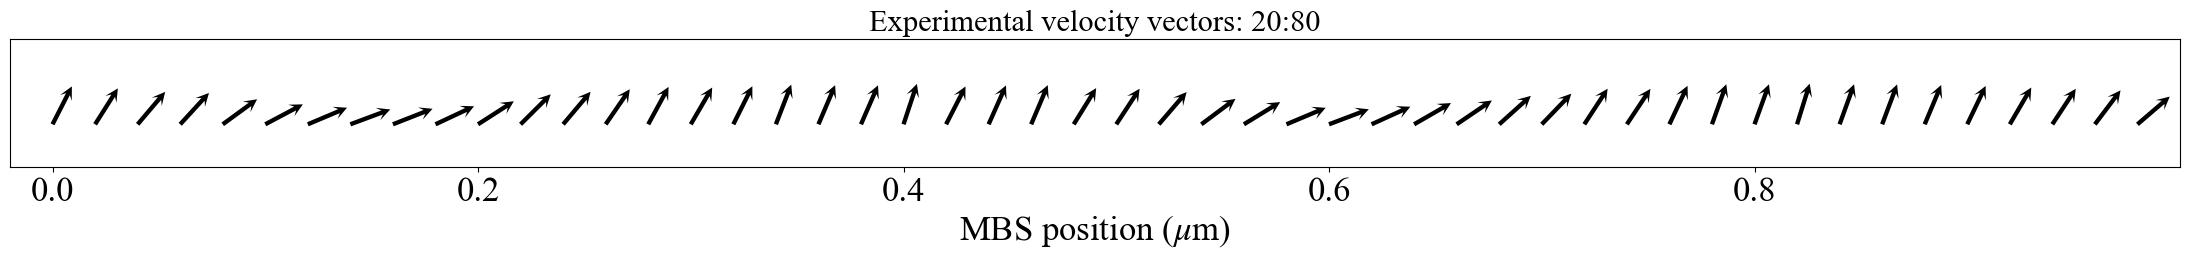

(<Figure size 2200x400 with 1 Axes>,
 <Axes: title={'center': 'Experimental velocity vectors: 20:80'}, xlabel='MBS position ($\\mu$m)'>)

In [26]:
plot_experimental_vectors(
    Vel_vec=Vel_vec_exp_20_80,
    split_ratio=(20, 80)
)

## Angles

### $\chi = \tan^{-1}[v(x)]$

In [104]:
def plot_experimental_angles(
    ax,
    x,
    mean_rates,
    std_rates,
    theta_deg=4.0,
    detect_eff_correction=0.62,
    label="Experiment",
    error_alpha=0.25
):
    mean1 = mean_rates[0]
    mean2 = mean_rates[1]

    std1 = std_rates[0]
    std2 = std_rates[1]

    correction = detect_eff_correction
    scale = np.sin(2 * np.radians(theta_deg))

    # ============================================================
    # Efficiency-corrected experimental velocity
    # ============================================================
    numerator = correction * mean1 - mean2
    denominator = correction * mean1 + mean2

    velocity = numerator / (scale * denominator)

    angle = np.degrees(
        np.arctan(velocity)
    )

    # ============================================================
    # Propagate uncertainty from the original channel rates
    # ============================================================
    dvel_dmean1 = (
        2 * correction * mean2
        / (scale * denominator**2)
    )

    dvel_dmean2 = (
        -2 * correction * mean1
        / (scale * denominator**2)
    )

    velocity_std = np.sqrt(
        (dvel_dmean1 * std1)**2
        +
        (dvel_dmean2 * std2)**2
    )

    angle_std = np.degrees(
        velocity_std
        / (1 + velocity**2)
    )

    # ============================================================
    # Plot
    # ============================================================
    band = ax.fill_between(
    x,
    angle - angle_std,
    angle + angle_std,
    alpha=error_alpha,
    zorder=1
    )

    line, = ax.plot(
        x,
        angle,
        "-",
        linewidth=2,
        alpha = 0.8,
        zorder=2
    )

    return velocity, angle, angle_std, line, band

def plot_theoretical_angles(
    ax,
    x,
    eta,
    theta_deg=4.0,
    fringe_start=0.0,
    step_nm=20.0,
    lambda_nm=925.0,
    label="Theory"
):
    phi0 = 2 * np.pi * fringe_start

    Vel_vec_th, Vel_mag_th, Vel_value_th, phi_th, rho_th, j_th, x_um_th = (
        CalculateTheoryVelocities(
            eta=eta,
            theta=theta_deg,
            phi0=phi0,
            N=len(x),
            step_nm=step_nm,
            lambda_nm=lambda_nm
        )
    )

    angle_th = np.degrees(
        np.arctan(Vel_value_th)
    )

    ax.plot(
        x,
        angle_th,
        "--",
        linewidth=2,
        label=label,
        zorder=3
    )

    return angle_th

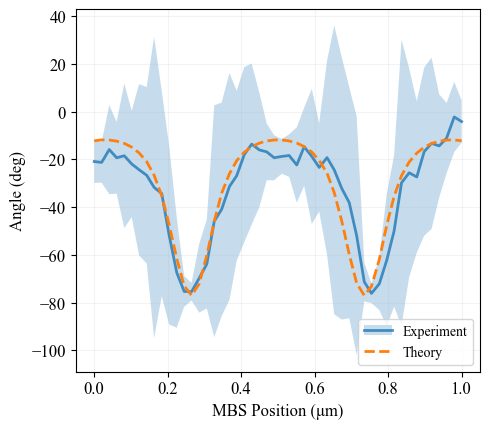

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_70_30, angle_70_30, angle_std_70_30, exp_line_70_30, exp_band_70_30 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_70_30,
        std_rates=veto_std_rates_70_30,
        theta_deg=4.0,
        detect_eff_correction=0.64,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_70_30 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.7,
    theta_deg=4.0,
    fringe_start=-0.06,
    #label="Theory"
)

theory_line_70_30 = ax.lines[-1]

ax.legend(
    [(exp_band_70_30, exp_line_70_30), theory_line_70_30],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_70-30.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

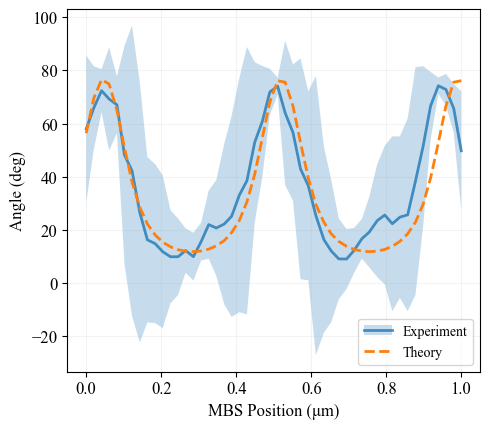

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_30_70, angle_30_70, angle_std_30_70, exp_line_30_70, exp_band_30_70 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_30_70,
        std_rates=veto_std_rates_30_70,
        theta_deg=4.0,
        detect_eff_correction=0.66,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_30_70 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.3,
    theta_deg=4.0,
    fringe_start=0.40,
    #label="Theory"
)

theory_line_30_70 = ax.lines[-1]

ax.legend(
    [(exp_band_30_70, exp_line_30_70), theory_line_30_70],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_30-70.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

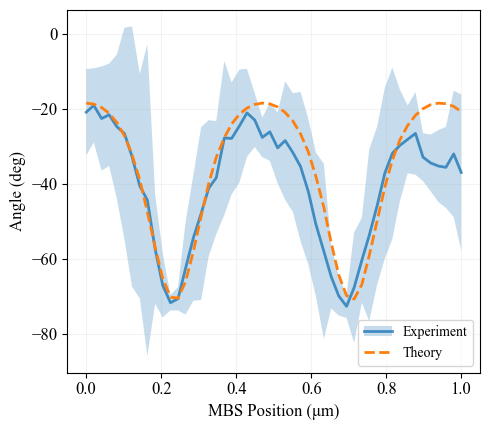

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_80_20, angle_80_20, angle_std_80_20, exp_line_80_20, exp_band_80_20 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_80_20,
        std_rates=veto_std_rates_80_20,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_80_20 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.8,
    theta_deg=4.0,
    fringe_start=0.0,
    #label="Theory"
)

theory_line_80_20 = ax.lines[-1]

ax.legend(
    [(exp_band_80_20, exp_line_80_20), theory_line_80_20],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_80-20.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

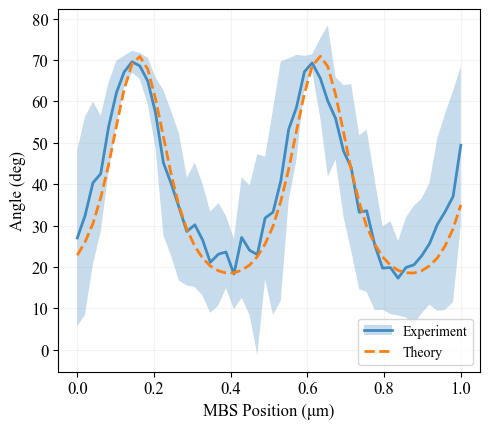

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_20_80, angle_20_80, angle_std_20_80, exp_line_20_80, exp_band_20_80 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_20_80,
        std_rates=veto_std_rates_20_80,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_20_80 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.2,
    theta_deg=4.0,
    fringe_start=0.16,
    #label="Theory"
)

theory_line_20_80 = ax.lines[-1]

ax.legend(
    [(exp_band_20_80, exp_line_20_80), theory_line_20_80],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_20-80.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

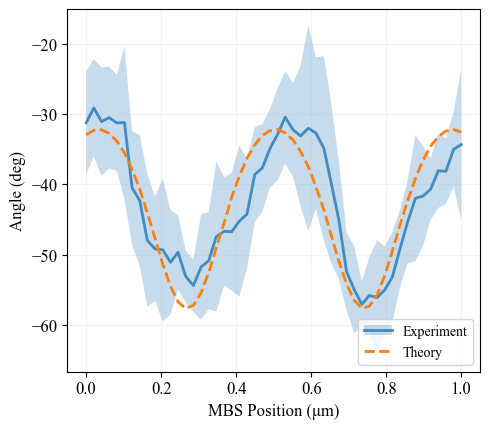

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_95_5, angle_95_5, angle_std_95_5, exp_line_95_5, exp_band_95_5 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_95_5,
        std_rates=veto_std_rates_95_5,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_95_5 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.95,
    theta_deg=4.0,
    fringe_start=-0.07,
    #label="Theory"
)

theory_line_95_5 = ax.lines[-1]

ax.legend(
    [(exp_band_95_5, exp_line_95_5), theory_line_95_5],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_95-5.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

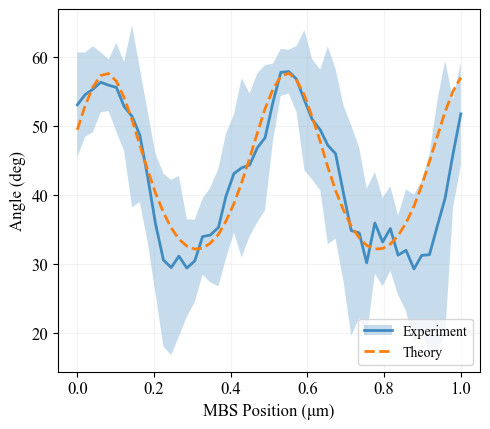

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_5_95, angle_5_95, angle_std_5_95, exp_line_5_95, exp_band_5_95 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_5_95,
        std_rates=veto_std_rates_5_95,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_5_95 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.05,
    theta_deg=4.0,
    fringe_start=0.34,
    #label="Theory"
)

theory_line_5_95 = ax.lines[-1]

ax.legend(
    [(exp_band_5_95, exp_line_5_95), theory_line_5_95],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_5-95.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

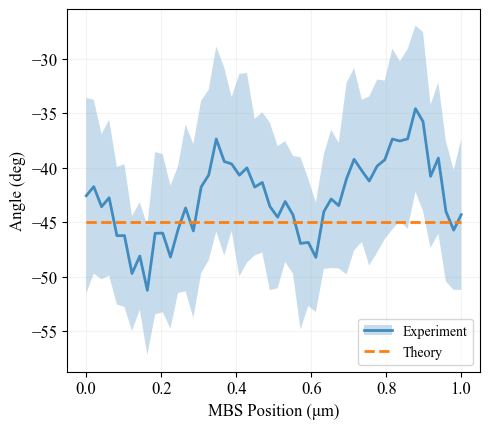

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_100_0, angle_100_0, angle_std_100_0, exp_line_100_0, exp_band_100_0 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_100_0,
        std_rates=veto_std_rates_100_0,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_100_0 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=1.0,
    theta_deg=4.0,
    fringe_start=0.0,
    #label="Theory"
)

theory_line_100_0 = ax.lines[-1]

ax.legend(
    [(exp_band_100_0, exp_line_100_0), theory_line_100_0],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_100-0.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()

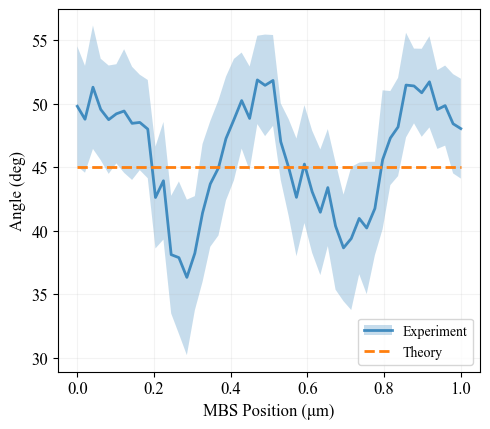

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4.4))

velocity_0_100, angle_0_100, angle_std_0_100, exp_line_0_100, exp_band_0_100 = (
    plot_experimental_angles(
        ax=ax,
        x=distArr_measured,
        mean_rates=veto_mean_rates_0_100,
        std_rates=veto_std_rates_0_100,
        theta_deg=4.0,
        detect_eff_correction=0.62,
        #label=r"Experiment $\pm 1\sigma$"
    )
)

angle_th_0_100 = plot_theoretical_angles(
    ax=ax,
    x=distArr_measured,
    eta=0.0,
    theta_deg=4.0,
    fringe_start=0.0,
    #label="Theory"
)

theory_line_0_100 = ax.lines[-1]

ax.legend(
    [(exp_band_0_100, exp_line_0_100), theory_line_0_100],
    [r"Experiment", "Theory"],
    handler_map={tuple: HandlerTuple(ndivide=1)},
    loc = "lower right"
)

ax.set_xlabel("MBS Position (μm)", fontsize=12)
ax.set_ylabel("Angle (deg)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.15)
#ax.legend()

fig.tight_layout()

# plt.savefig(
#     "forExpt_draft/angles_v2/angles_0-100.pdf",
#     format="pdf",
#     transparent=True,
#     bbox_inches="tight",
#     pad_inches=0
# )
plt.show()